In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from lightgbm import LGBMClassifier
from sklearn.cluster import KMeans
sns.set_theme()

In [2]:
df_map = pd.read_csv(
    r'C:\Fause\Programas\EngSoft\repos\ML-Transportes\PBIC\acidentes_pbic_somas.csv',
    encoding='utf-8',
    parse_dates=['data_inversa'],
    dayfirst=True,
    low_memory=False
)

print("Shape inicial:", df_map.shape)


Shape inicial: (1678326, 53)


In [3]:
df_map = df_map.copy()

df_map = df_map.drop_duplicates(subset=["id", "pesid"])

In [4]:
import pandas as pd
import numpy as np
import folium
from folium.plugins import MarkerCluster
from datetime import datetime

# =============================
# Limpeza da BR
# =============================

def limpar_br(df):
    return (
        df["br"]
        .astype(str)
        .str.replace(r'\.0$', '', regex=True)
        .str.replace("BR-", "", regex=False)
        .str.strip()
    )

df_map["br"] = limpar_br(df_map)

# =============================
# FILTRO DE RODOVIA
# =============================

br_escolhida = input("Digite a BR que deseja visualizar (ex: 116) ou pressione ENTER para todas: ")

df_filtrado = df_map.copy()

if br_escolhida.strip() != "":
    df_filtrado = df_filtrado[df_filtrado["br"] == br_escolhida.strip()]
    print(f"Filtrando apenas BR {br_escolhida}")
else:
    print("Mostrando todas as rodovias")

if df_filtrado.empty:
    print("Nenhum dado encontrado para essa BR.")
    exit()

# =============================
# Limpeza coordenadas
# =============================

cols = ["latitude", "longitude", "km"]

for col in cols:
    df_filtrado[col] = pd.to_numeric(
        df_filtrado[col].astype(str).str.replace(",", "."),
        errors="coerce"
    )

df_filtrado = df_filtrado.dropna(subset=["latitude", "longitude", "km"])

# =============================
# KM BIN
# =============================

df_filtrado["km_bin"] = ((df_filtrado["km"] // 5) * 5).astype(int)

# =============================
# Índice de severidade (AGORA FILTRADO)
# =============================

df_filtrado["severity_index"] = (
    4 * df_filtrado["Sum_Mortos"] +
    2 * df_filtrado["Sum_Feridos_Graves"] +
    1 * df_filtrado["Sum_Feridos_Leves"]
)

# =============================
# Agrupamento (AGORA FILTRADO)
# =============================

df_segmento = df_filtrado.groupby(["br", "uf", "km_bin"]).agg(
    severity_index=("severity_index", "mean"),
    n_acidentes=("severity_index", "count"),
    total_mortos=("Sum_Mortos", "sum"),
    total_feridos_graves=("Sum_Feridos_Graves", "sum"),
    total_feridos_leves=("Sum_Feridos_Leves", "sum")
).reset_index()
# =============================
# Classificação de veículos
# =============================

caminhao = ["Caminhão", "Caminhão-trator"]
carros_leves = ["Automóvel"]
caminhonetes = ["Caminhonete", "Camioneta", "Utilitário"]
motos = ["Motocicleta", "Motoneta"]
ciclomotores = ["Ciclomotor", "Triciclo", "Quadriciclo"]

# NOVO 🚍
onibus = ["Ônibus", "Micro-ônibus"]

# =============================
# Criar mapa
# =============================

m = folium.Map(
    location=[df_filtrado["latitude"].median(), df_filtrado["longitude"].median()],
    zoom_start=6
)

# =============================
# Camadas
# =============================

layer_todos = MarkerCluster(name="🔴 Todos acidentes com mortos").add_to(m)
layer_caminhao = MarkerCluster(name="🚛 Caminhões").add_to(m)
layer_carro = MarkerCluster(name="🚗 Automóveis").add_to(m)
layer_caminhonete = MarkerCluster(name="🚙 Caminhonetes").add_to(m)
layer_moto = MarkerCluster(name="🏍 Motocicletas").add_to(m)
layer_ciclomotor = MarkerCluster(name="🛵 Ciclomotores").add_to(m)

# NOVO 🚍
layer_onibus = MarkerCluster(name="🚌 Ônibus").add_to(m)

# =============================
# Agrupamento auxiliar
# =============================

segmentos_grupo = df_filtrado.groupby(["br", "uf", "km_bin"])

# =============================
# Plotagem
# =============================

for _, row in df_segmento.iterrows():

    try:
        grupo = segmentos_grupo.get_group(
            (row["br"], row["uf"], row["km_bin"])
        )
    except KeyError:
        continue

    lat = grupo["latitude"].median()
    lon = grupo["longitude"].median()

    if np.isnan(lat) or np.isnan(lon):
        continue

    # Flags de veículos
    tem_caminhao = grupo["tipo_veiculo"].isin(caminhao).any()
    tem_carro = grupo["tipo_veiculo"].isin(carros_leves).any()
    tem_caminhonete = grupo["tipo_veiculo"].isin(caminhonetes).any()
    tem_moto = grupo["tipo_veiculo"].isin(motos).any()
    tem_ciclomotor = grupo["tipo_veiculo"].isin(ciclomotores).any()
    tem_onibus = grupo["tipo_veiculo"].isin(onibus).any()  # NOVO

    # Popup
    veiculos = grupo["tipo_veiculo"].value_counts().head(3)
    veiculo_txt = "<br>".join([f"{v}: {c}" for v, c in veiculos.items()])

    popup_html = f"""
    <b>BR:</b> {row['br']} - {row['uf']} | <b>KM:</b> {row['km_bin']}<br>
    <b>Total de acidentes:</b> {row['n_acidentes']}<br>
    <b>Total de mortos:</b> {row['total_mortos']}<br>
    <hr><b>Top Veículos:</b><br>{veiculo_txt}
    """

    radius = 7 + (np.log1p(row["total_mortos"]) * 3)

    # Geral
    folium.CircleMarker(
        location=[lat, lon],
        radius=radius,
        color="red",
        fill=True,
        fill_opacity=0.7,
        popup=folium.Popup(popup_html, max_width=250)
    ).add_to(layer_todos)

    # Camadas específicas
    if tem_caminhao:
        folium.CircleMarker([lat, lon], radius=radius, color="purple", fill=True, fill_opacity=0.7, popup=popup_html).add_to(layer_caminhao)

    if tem_carro:
        folium.CircleMarker([lat, lon], radius=radius, color="blue", fill=True, fill_opacity=0.7, popup=popup_html).add_to(layer_carro)

    if tem_caminhonete:
        folium.CircleMarker([lat, lon], radius=radius, color="darkgreen", fill=True, fill_opacity=0.7, popup=popup_html).add_to(layer_caminhonete)

    if tem_moto:
        folium.CircleMarker([lat, lon], radius=radius, color="orange", fill=True, fill_opacity=0.7, popup=popup_html).add_to(layer_moto)

    if tem_ciclomotor:
        folium.CircleMarker([lat, lon], radius=radius, color="black", fill=True, fill_opacity=0.7, popup=popup_html).add_to(layer_ciclomotor)

    # NOVO 🚍
    if tem_onibus:
        folium.CircleMarker(
            [lat, lon],
            radius=radius,
            color="pink",
            fill=True,
            fill_opacity=0.7,
            popup=popup_html
        ).add_to(layer_onibus)

# =============================
# Controle
# =============================

folium.LayerControl(collapsed=False).add_to(m)

# =============================
# Salvar
# =============================

#path = f"C:/Fause/Programas/EngSoft/repos/ML-Transportes/PBIC\EtapaML\Final\MapsCarro/mapa_mortos_carros.html"

#m.save(path)

#print(f"Mapa gerado com sucesso em: {path}")

Mostrando todas as rodovias


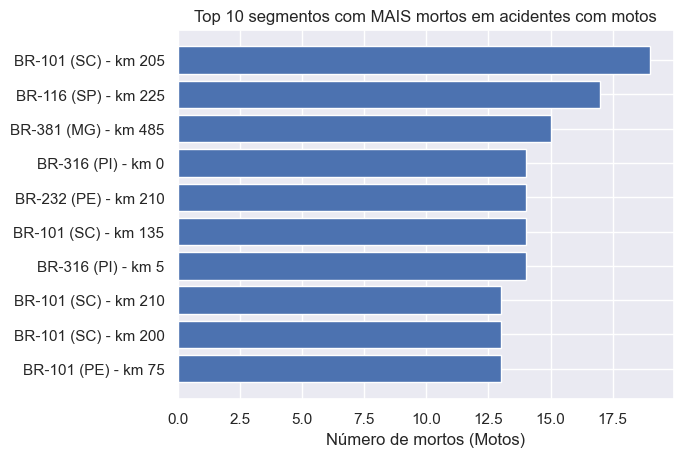

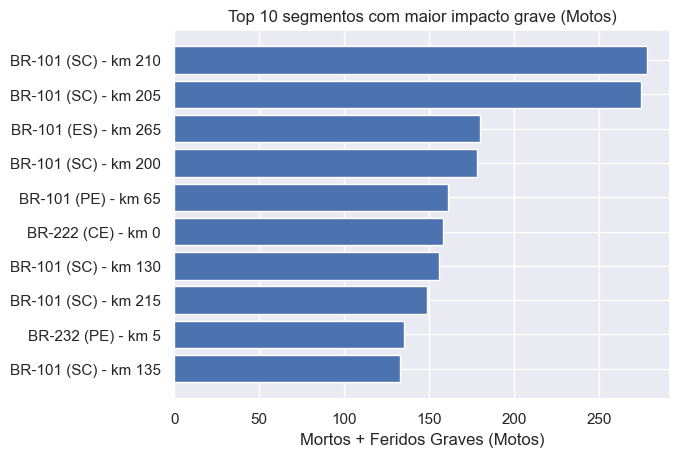

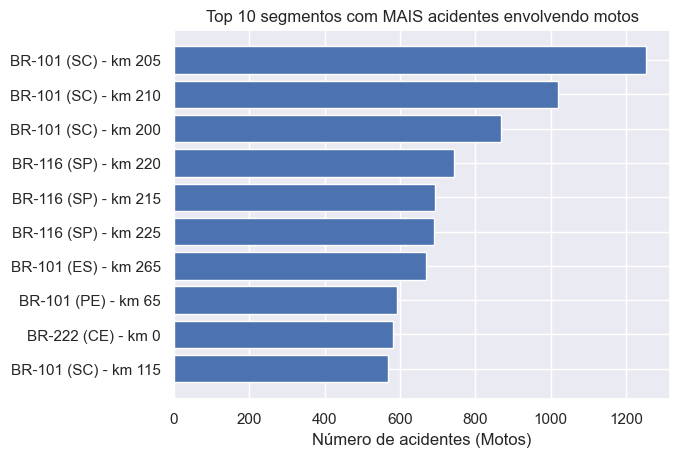

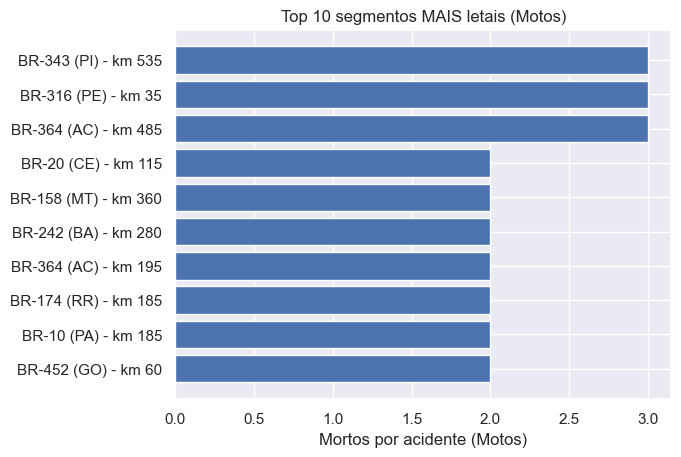

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =============================
# 1️⃣ Definir veículos (motos)
# =============================

motos = ["Motocicleta", "Motoneta"]

# =============================
# 2️⃣ Filtrar base original
# =============================

df_moto = df_filtrado[
    df_filtrado["tipo_veiculo"].isin(motos)
].copy()

# Remover possíveis inconsistências
df_moto = df_moto.dropna(subset=["br", "uf", "km_bin"])

# =============================
# 3️⃣ Criar índice de severidade
# =============================

df_moto["severity_index"] = (
    4 * df_moto["Sum_Mortos"] +
    2 * df_moto["Sum_Feridos_Graves"] +
    1 * df_moto["Sum_Feridos_Leves"]
)

# =============================
# 4️⃣ Agrupar por segmento
# =============================

df_segmento_moto = df_moto.groupby(
    ["br", "uf", "km_bin"]
).agg(
    n_acidentes=("Sum_Total_Vitimas", "count"),
    total_mortos=("Sum_Mortos", "sum"),
    total_feridos_graves=("Sum_Feridos_Graves", "sum"),
    total_feridos_leves=("Sum_Feridos_Leves", "sum")
).reset_index()

# =============================
# 5️⃣ Criar nome do segmento
# =============================

df_segmento_moto["segmento"] = (
    "BR-" + df_segmento_moto["br"].astype(str) + " (" +
    df_segmento_moto["uf"] + ") - km " +
    df_segmento_moto["km_bin"].astype(str)
)

# =============================
# 6️⃣ TOP 10 - MAIS MORTOS (MOTOS)
# =============================

top10_mortos_moto = df_segmento_moto.sort_values(
    "total_mortos", ascending=False
).head(10)

plt.figure()

plt.barh(
    top10_mortos_moto["segmento"],
    top10_mortos_moto["total_mortos"]
)

plt.xlabel("Número de mortos (Motos)")
plt.title("Top 10 segmentos com MAIS mortos em acidentes com motos")
plt.gca().invert_yaxis()

plt.show()

# =============================
# 7️⃣ TOP 10 - IMPACTO GRAVE
# =============================

df_segmento_moto["impacto_grave"] = (
    df_segmento_moto["total_mortos"] +
    df_segmento_moto["total_feridos_graves"]
)

top10_impacto_moto = df_segmento_moto.sort_values(
    "impacto_grave", ascending=False
).head(10)

plt.figure()

plt.barh(
    top10_impacto_moto["segmento"],
    top10_impacto_moto["impacto_grave"]
)

plt.xlabel("Mortos + Feridos Graves (Motos)")
plt.title("Top 10 segmentos com maior impacto grave (Motos)")
plt.gca().invert_yaxis()

plt.show()

# =============================
# 8️⃣ TOP 10 - MAIS ACIDENTES
# =============================

top10_acidentes_moto = df_segmento_moto.sort_values(
    "n_acidentes", ascending=False
).head(10)

plt.figure()

plt.barh(
    top10_acidentes_moto["segmento"],
    top10_acidentes_moto["n_acidentes"]
)

plt.xlabel("Número de acidentes (Motos)")
plt.title("Top 10 segmentos com MAIS acidentes envolvendo motos")
plt.gca().invert_yaxis()

plt.show()

# =============================
# 9️⃣ EXTRA - TAXA DE RISCO
# =============================

df_segmento_moto["mortos_por_acidente"] = (
    df_segmento_moto["total_mortos"] /
    df_segmento_moto["n_acidentes"].replace(0, np.nan)
)

top10_risco_moto = df_segmento_moto.sort_values(
    "mortos_por_acidente", ascending=False
).head(10)

plt.figure()

plt.barh(
    top10_risco_moto["segmento"],
    top10_risco_moto["mortos_por_acidente"]
)

plt.xlabel("Mortos por acidente (Motos)")
plt.title("Top 10 segmentos MAIS letais (Motos)")
plt.gca().invert_yaxis()

plt.show()

In [6]:
def consulta_por_variavel(df_original, df_top10, coluna_consulta):
    """
    df_original: df_caminhao (ou df_filtrado já tratado)
    df_top10: top10_impacto_caminhao
    coluna_consulta: string (ex: 'Fabricante', 'tipo_acidente')
    """

    # =============================
    # 1️⃣ Filtrar apenas segmentos do Top 10
    # =============================
    
    df_filtrado_top = df_original.merge(
        df_top10[["br", "uf", "km_bin"]],
        on=["br", "uf", "km_bin"],
        how="inner"
    )

    # =============================
    # 2️⃣ Agrupar dinamicamente
    # =============================
    
    resultado = df_filtrado_top.groupby(
        ["br", "uf", "km_bin", coluna_consulta]
    ).size().reset_index(name="quantidade")

    # =============================
    # 3️⃣ Criar nome do segmento
    # =============================
    
    resultado["segmento"] = (
        "BR-" + resultado["br"].astype(str) + " (" +
        resultado["uf"] + ") - km " +
        resultado["km_bin"].astype(str)
    )

    # =============================
    # 4️⃣ Ordenar resultados
    # =============================
    
    resultado = resultado.sort_values(
        ["segmento", "quantidade"],
        ascending=[True, False]
    )

    return resultado

In [7]:
res_fabricante = consulta_por_variavel(
    df_moto,
    top10_impacto_moto,
    "Fabricante"
)

for segmento, grupo in res_fabricante.groupby("segmento"):
    print(f"\n===== {segmento} =====")
    print(grupo[["Fabricante", "quantidade"]].to_string(index=False))


===== BR-101 (ES) - km 265 =====
     Fabricante  quantidade
          HONDA         477
         YAMAHA         143
  Não Informado          55
          MOTTU          13
         SUZUKI          12
       KAWASAKI           7
            BMW           5
            JTZ           4
       SHINERAY           4
         BASHAN           2
HARLEY-DAVIDSON           2
          ROYAL           2
        SUNDOWN           2
          BAJAJ           1
          DAFRA           1
          DAYUN           1
            IMP           1
        RENAULT           1
        TRIUMPH           1

===== BR-101 (PE) - km 65 =====
            Fabricante  quantidade
                 HONDA         455
                YAMAHA         109
         Não Informado          22
                 MOTTU          14
                SUZUKI           5
                   BMW           4
                 DAFRA           3
              SHINERAY           2
JTA-SUZUKI GSX-S750 AZ           1
              KAWASAKI 

In [8]:
res_fabricante = consulta_por_variavel(
    df_moto,
    top10_impacto_moto,
    "tipo_veiculo"
)

for segmento, grupo in res_fabricante.groupby("segmento"):
    print(f"\n===== {segmento} =====")
    print(grupo[["tipo_veiculo", "quantidade"]].to_string(index=False))


===== BR-101 (ES) - km 265 =====
tipo_veiculo  quantidade
 Motocicleta         649
    Motoneta          85

===== BR-101 (PE) - km 65 =====
tipo_veiculo  quantidade
 Motocicleta         603
    Motoneta          13

===== BR-101 (SC) - km 130 =====
tipo_veiculo  quantidade
 Motocicleta         373
    Motoneta         167

===== BR-101 (SC) - km 135 =====
tipo_veiculo  quantidade
 Motocicleta         345
    Motoneta          88

===== BR-101 (SC) - km 200 =====
tipo_veiculo  quantidade
 Motocicleta         724
    Motoneta         161

===== BR-101 (SC) - km 205 =====
tipo_veiculo  quantidade
 Motocicleta        1043
    Motoneta         232

===== BR-101 (SC) - km 210 =====
tipo_veiculo  quantidade
 Motocicleta         840
    Motoneta         209

===== BR-101 (SC) - km 215 =====
tipo_veiculo  quantidade
 Motocicleta         408
    Motoneta         123

===== BR-222 (CE) - km 0 =====
tipo_veiculo  quantidade
 Motocicleta         586
    Motoneta          19

===== BR-232 (PE) - k

In [9]:
res_fabricante = consulta_por_variavel(
    df_moto,
    top10_impacto_moto,
    "causa_acidente"
)

for segmento, grupo in res_fabricante.groupby("segmento"):
    print(f"\n===== {segmento} =====")
    print(grupo[["causa_acidente", "quantidade"]].to_string(index=False))


===== BR-101 (ES) - km 265 =====
                                                              causa_acidente  quantidade
                                                 Manobra de mudança de faixa          98
                                    Reação tardia ou ineficiente do condutor          83
                                              Ausência de reação do condutor          78
                    Condutor deixou de manter distância do veículo da frente          68
                       Trafegar com motocicleta (ou similar) entre as faixas          63
                                                 Falta de Atenção à Condução          62
                     Condutor desrespeitou a iluminação vermelha do semáforo          51
                   Acessar a via sem observar a presença dos outros veículos          43
                                      Pedestre cruzava a pista fora da faixa          28
                           Desobediência às normas de trânsito pelo condutor

In [10]:
res_fabricante = consulta_por_variavel(
    df_moto,
    top10_impacto_moto,
    "tipo_acidente"
)

for segmento, grupo in res_fabricante.groupby("segmento"):
    print(f"\n===== {segmento} =====")
    print(grupo[["tipo_acidente", "quantidade"]].to_string(index=False))


===== BR-101 (ES) - km 265 =====
                 tipo_acidente  quantidade
  Queda de ocupante de veículo         291
 Colisão lateral mesmo sentido         102
              Colisão traseira         100
           Colisão transversal          84
                    Tombamento          59
     Atropelamento de Pedestre          56
               Colisão lateral          19
            Colisão com objeto           7
               Colisão frontal           6
Colisão lateral sentido oposto           5
                 Engavetamento           3
       Atropelamento de Animal           2

===== BR-101 (PE) - km 65 =====
                  tipo_acidente  quantidade
   Queda de ocupante de veículo         299
               Colisão traseira         118
  Colisão lateral mesmo sentido          78
                     Tombamento          58
      Atropelamento de Pedestre          15
            Colisão transversal          15
                Colisão lateral          11
                  Enga

In [11]:
res_fabricante = consulta_por_variavel(
    df_moto,
    top10_impacto_moto,
    "fase_dia"
)

for segmento, grupo in res_fabricante.groupby("segmento"):
    print(f"\n===== {segmento} =====")
    print(grupo[["fase_dia", "quantidade"]].to_string(index=False))


===== BR-101 (ES) - km 265 =====
   fase_dia  quantidade
  Pleno dia         489
Plena Noite         171
  Anoitecer          58
  Amanhecer          16

===== BR-101 (PE) - km 65 =====
   fase_dia  quantidade
  Pleno dia         442
Plena Noite         142
  Anoitecer          21
  Amanhecer          11

===== BR-101 (SC) - km 130 =====
   fase_dia  quantidade
  Pleno dia         322
Plena Noite         179
  Anoitecer          30
  Amanhecer           9

===== BR-101 (SC) - km 135 =====
   fase_dia  quantidade
  Pleno dia         268
Plena Noite         132
  Anoitecer          27
  Amanhecer           6

===== BR-101 (SC) - km 200 =====
   fase_dia  quantidade
  Pleno dia         576
Plena Noite         230
  Anoitecer          60
  Amanhecer          19

===== BR-101 (SC) - km 205 =====
   fase_dia  quantidade
  Pleno dia         793
Plena Noite         364
  Anoitecer          85
  Amanhecer          33

===== BR-101 (SC) - km 210 =====
   fase_dia  quantidade
  Pleno dia        

In [12]:
res_fabricante = consulta_por_variavel(
    df_moto,
    top10_impacto_moto,
    "condicao_metereologica"
)

for segmento, grupo in res_fabricante.groupby("segmento"):
    print(f"\n===== {segmento} =====")
    print(grupo[["condicao_metereologica", "quantidade"]].to_string(index=False))


===== BR-101 (ES) - km 265 =====
condicao_metereologica  quantidade
             Céu Claro         425
               Nublado         156
                   Sol          87
                 Chuva          46
        Garoa/Chuvisco          10
              Ignorado          10

===== BR-101 (PE) - km 65 =====
condicao_metereologica  quantidade
             Céu Claro         399
                   Sol          77
               Nublado          75
                 Chuva          42
        Garoa/Chuvisco          17
              Ignorado           6

===== BR-101 (SC) - km 130 =====
condicao_metereologica  quantidade
             Céu Claro         291
               Nublado         140
                   Sol          42
                 Chuva          38
        Garoa/Chuvisco          25
              Ignorado           3
      Nevoeiro/Neblina           1

===== BR-101 (SC) - km 135 =====
condicao_metereologica  quantidade
             Céu Claro         235
               Nublado   

In [13]:
res_fabricante = consulta_por_variavel(
    df_moto,
    top10_impacto_moto,
    "tipo_pista"
)

for segmento, grupo in res_fabricante.groupby("segmento"):
    print(f"\n===== {segmento} =====")
    print(grupo[["tipo_pista", "quantidade"]].to_string(index=False))


===== BR-101 (ES) - km 265 =====
tipo_pista  quantidade
  Múltipla         417
     Dupla         300
   Simples          17

===== BR-101 (PE) - km 65 =====
tipo_pista  quantidade
     Dupla         385
  Múltipla         197
   Simples          34

===== BR-101 (SC) - km 130 =====
tipo_pista  quantidade
     Dupla         213
  Múltipla         193
   Simples         134

===== BR-101 (SC) - km 135 =====
tipo_pista  quantidade
     Dupla         216
  Múltipla         143
   Simples          74

===== BR-101 (SC) - km 200 =====
tipo_pista  quantidade
  Múltipla         508
     Dupla         319
   Simples          58

===== BR-101 (SC) - km 205 =====
tipo_pista  quantidade
  Múltipla         830
     Dupla         379
   Simples          66

===== BR-101 (SC) - km 210 =====
tipo_pista  quantidade
  Múltipla         636
     Dupla         337
   Simples          76

===== BR-101 (SC) - km 215 =====
tipo_pista  quantidade
  Múltipla         247
     Dupla         211
   Simples      

In [14]:
res_fabricante = consulta_por_variavel(
    df_moto,
    top10_impacto_moto,
    "ano_fabricacao_veiculo"
)

for segmento, grupo in res_fabricante.groupby("segmento"):
    print(f"\n===== {segmento} =====")
    print(grupo[["ano_fabricacao_veiculo", "quantidade"]].to_string(index=False))


===== BR-101 (ES) - km 265 =====
 ano_fabricacao_veiculo  quantidade
                    0.0          83
                 2023.0          51
                 2022.0          50
                 2011.0          45
                 2019.0          43
                 2008.0          41
                 2010.0          37
                 2012.0          36
                 2020.0          36
                 2018.0          35
                 2014.0          34
                 2013.0          31
                 2024.0          27
                 2015.0          26
                 2021.0          26
                 2009.0          24
                 2017.0          21
                 2016.0          20
                 2007.0          14
                 2006.0          12
                 2005.0          11
                 2000.0           6
                 2001.0           5
                 2004.0           5
                 2002.0           4
                 2003.0       

In [15]:
res_fabricante = consulta_por_variavel(
    df_moto,
    top10_impacto_moto,
    "Modelo_Grupo"
)

for segmento, grupo in res_fabricante.groupby("segmento"):
    print(f"\n===== {segmento} =====")
    print(grupo[["Modelo_Grupo", "quantidade"]].to_string(index=False))


===== BR-101 (ES) - km 265 =====
                               Modelo_Grupo  quantidade
                              Não Informado          42
                                 CG 160 FAN          27
                               CG 160 START          22
                             CG 150 FAN ESI          18
                               CG 160 TITAN          18
                      CG 160 FAN/CG 160 FAN          16
                                FAZER YS250          13
                                 FZ25 FAZER          13
                Não Informado/Não Informado          13
                            YS150 FAZER SED          13
                CG 125 FAN ES/CG 125 FAN ES          12
                              CG 125 FAN KS          12
                                 SPORT 110I          12
                                    XRE 300          11
                CG 125 FAN KS/CG 125 FAN KS          10
                             CG150 FAN ESDI          10
              

In [16]:
res_fabricante = consulta_por_variavel(
    df_moto,
    top10_impacto_moto,
    "Modelo"
)

for segmento, grupo in res_fabricante.groupby("segmento"):
    print(f"\n===== {segmento} =====")
    print(grupo[["Modelo", "quantidade"]].to_string(index=False))


===== BR-101 (ES) - km 265 =====
       Modelo  quantidade
           CG         257
           NO          55
          XRE          29
          BIZ          28
        CG150          28
          PCX          26
           CB          23
       NXR150          22
        YS150          20
        FAZER          19
         FZ25          16
       YBR150          15
          CBX          14
        SPORT          12
       SUZUKI          12
       CB250F          11
       XTZ150          11
       XTZ250           8
         FZ15           7
         MT03           7
        ELITE           6
         NMAX           6
          YBR           5
       YBR125           5
          NEO           4
        NINJA           4
       NXR160           4
       CB300F           3
      CROSSER           3
       FACTOR           3
     FAZER250           3
          POP           3
     SHINERAY           3
      YBR125I           3
          ADV           2
       BASHAN           2
    

In [17]:
def consulta_multiplas_variaveis(df_original, df_top10, colunas):
    """
    colunas: lista de colunas
    ex: ['Fabricante', 'Modelo_Grupo', 'Modelo', 'ano_fabricacao_veiculo']
    """

    # =============================
    # 1️⃣ Filtrar Top 10
    # =============================
    
    df_filtrado_top = df_original.merge(
        df_top10[["br", "uf", "km_bin"]],
        on=["br", "uf", "km_bin"],
        how="inner"
    )

    # =============================
    # 2️⃣ Agrupar por múltiplas colunas
    # =============================
    
    resultado = df_filtrado_top.groupby(
        ["br", "uf", "km_bin"] + colunas
    ).size().reset_index(name="quantidade")

    # =============================
    # 3️⃣ Criar segmento
    # =============================
    
    resultado["segmento"] = (
        "BR-" + resultado["br"].astype(str) + " (" +
        resultado["uf"] + ") - km " +
        resultado["km_bin"].astype(str)
    )

    # =============================
    # 4️⃣ Ordenar
    # =============================
    
    resultado = resultado.sort_values(
        ["segmento", "quantidade"],
        ascending=[True, False]
    )

    return resultado

In [18]:
colunas = [
    "Fabricante",
    "Modelo_Grupo",
    "Modelo",
    "ano_fabricacao_veiculo"
]


res_veiculos = consulta_multiplas_variaveis(
    df_moto,
    top10_impacto_moto,
    colunas
)

In [19]:
for segmento, grupo in res_veiculos.groupby("segmento"):
    print(f"\n===== {segmento} =====")
    print(
        grupo[colunas + ["quantidade"]]
        .head(10)  # top 5
        .to_string(index=False)
    )


===== BR-101 (ES) - km 265 =====
   Fabricante                    Modelo_Grupo Modelo  ano_fabricacao_veiculo  quantidade
Não Informado                   Não Informado     NO                     0.0          42
Não Informado     Não Informado/Não Informado     NO                     0.0          13
        HONDA                    CG 160 TITAN     CG                  2022.0           9
        HONDA                      CG 160 FAN     CG                  2022.0           8
        HONDA                  CG 150 FAN ESI     CG                  2011.0           7
        HONDA           CG 160 FAN/CG 160 FAN     CG                  2018.0           7
        MOTTU                      SPORT 110I  SPORT                  2023.0           7
        HONDA CBX 250 TWISTER/CBX 250 TWISTER    CBX                  2008.0           6
        HONDA           CG 125 FAN/CG 125 FAN     CG                  2008.0           6
        HONDA                    CG 160 START     CG                  2024.0